https://horizon.kias.re.kr/17443/

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
        return 1.0/(1.0 + np.exp(-x))

def init_network(input_dim, hidden_dim, output_dim):
    W = np.random.randn(input_dim, hidden_dim)
    b = np.random.randn(hidden_dim)
    V = np.random.randn(hidden_dim, output_dim )
    c = np.random.randn(output_dim)
    return W, b, V, c
    
def forward(x, W, b, V, c):
    z = sigmoid(np.matmul(x, W) - b)
    y = sigmoid(np.matmul(z, V) - c)
    return z, y

def backward(x, true_y, W, b, V, c, lr=0.01):
    z, y = forward(x, W, b, V, c)
    error_y = (true_y - y)*y*(1-y)
    error_z = error_y.dot(V.T)*z*(1-z)   
    
    V = V + lr * np.matmul(z.T, error_y)
    W = W + lr * np.matmul(x.T, error_z)
    c = c + lr * np.sum(error_y,axis=0)*(-1.)
    b = b + lr * np.sum(error_z,axis=0)*(-1.)
    return W, b, V, c 

In [17]:
from tensorflow.keras import datasets
mnist = datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()
samples, labels = train_x, train_y

#from sklearn.datasets import fetch_openml
#mnist = fetch_openml('mnist_784') # 손글씨 데이터
#samples, labels = mnist.data, mnist.target # data: 28x28 이미지, target: true label
# samples = samples.values/255 # 픽셀은 255까지의 숫자를 갖고 있는데 0~1사이 값을 가지도록 정규화 (에러나서 주석처리)

# print(labels[0:2])

sample_num = samples.shape[0] # 샘플이 몇 개 있는가 (train 6만, test 1만)
print(sample_num)

# 원핫인코딩으로 출력을 표현
# 출력을 정수로 쓰면 에러 구할 때 출력을 모두 동등하게 생각하지 않게 됨
# 반면 원핫인코딩은 인코딩 자체가 모두 동등
one_hot_labels = np.zeros([sample_num,10]) # 샘플 개수만큼 0을 집어 넣음 (N행 10열)
# 각 샘플에서 라벨이 있는 자릿수에만 1을 넣음
for i in range(sample_num):
    one_hot_labels[i, int(labels[i])] = 1.

print(labels[0]) # 정수 표현
print(one_hot_labels[0]) # 원핫인코딩 표현

11493376/11490434 [==============================] - 0s 0us/step
60000
5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [21]:
samples.shape

(60000, 28, 28)

In [22]:
labels.shape

(60000,)

Label: 4, one_hot_encoding: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.].
(28, 28)
(28, 28)


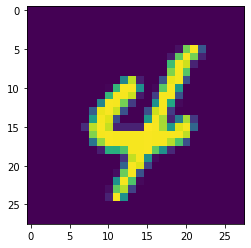

In [23]:
index = 139 #You may change the index from 0 to 69999
img = samples[index,:] # :은 모든 픽셀을 표현하라는 의미
print( 'Label: %s, one_hot_encoding: %s.'%(labels[index], one_hot_labels[index,:]) )

print(img.shape)
img = img.reshape(28,28)
print(img.shape)

plt.imshow(img)
plt.show()

<ipython-input-1-dee35839ba7e>:5: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(-x))


epoch: 0/200, error: 307/400
epoch: 10/200, error: 270/400
epoch: 20/200, error: 257/400
epoch: 30/200, error: 238/400
epoch: 40/200, error: 227/400
epoch: 50/200, error: 237/400
epoch: 60/200, error: 235/400
epoch: 70/200, error: 226/400
epoch: 80/200, error: 225/400
epoch: 90/200, error: 230/400
epoch: 100/200, error: 219/400
epoch: 110/200, error: 245/400
epoch: 120/200, error: 250/400
epoch: 130/200, error: 246/400
epoch: 140/200, error: 240/400
epoch: 150/200, error: 239/400
epoch: 160/200, error: 261/400
epoch: 170/200, error: 249/400
epoch: 180/200, error: 263/400
epoch: 190/200, error: 246/400


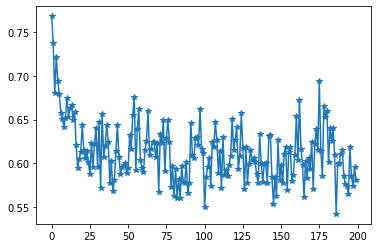

In [24]:
batch_size = 400 # 전체 데이터를 넣지 말고 한 번에 임의의 400개씩만 뽑아서 넣음 -> SGD 사용. local에 빠지지 않도록
epoch_num = 200

W, b, V, c = init_network(input_dim=784, hidden_dim=200, output_dim=10)
epoch_dat = []
error_dat = []

# 그냥 7만개 중에 200 샘플을 뽑는 게 아니라, 전체 7만장 중에 400개씩 뽑을 수 있는 횟수, 즉 7만/400번만큼 업데이트 하는 것을 한 epoch로 봄
for epoch in range(epoch_num):
    for a in range(int(sample_num/batch_size)):
        
        start = np.random.randint(50000)
        x = samples[start:start+batch_size, :] # 다른 방법으로 400개를 뽑을 수도 있음
        x = x.reshape(x.shape[0],784)
        true_y = one_hot_labels[start:start+batch_size,:] # 동일한 인덱스

        W, b, V, c = backward(x, true_y, W, b, V, c, lr=0.02)
        z, y = forward(x, W, b, V, c)
        train_error = np.sum(np.abs(true_y - y))
    
    epoch_dat.append(epoch)
    error_dat.append(train_error/batch_size)        
    
    if epoch % 10 == 0: # 10 epoch마다 error rate를 표시하도록
        print( 'epoch: %d/%d, error: %d/%d'%(epoch, epoch_num, train_error, batch_size))

plt.plot(epoch_dat, error_dat, '-*')
plt.show()

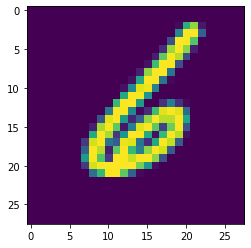

true_label = 6, predicted_label =6


<ipython-input-1-dee35839ba7e>:5: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(-x))


In [25]:
# prediction
index = 999 # 아무 이미지나 뽑기
img = samples[index,:]
true_label = labels[index]

plt.imshow(img.reshape(28,28))
plt.show()

x = img.reshape(784)
z, y = forward(x, W, b, V, c) # 학습된 파라미터를 가지고 y를 prediction
print('true_label = %s, predicted_label =%d' %(true_label, np.argmax(y))) # 원핫인코딩이므로 출력값에서 가장 큰 값을 가진 것, 즉 1인 것에 해당하는 값을 알려줌 -> argmax


<ipython-input-1-dee35839ba7e>:5: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(-x))


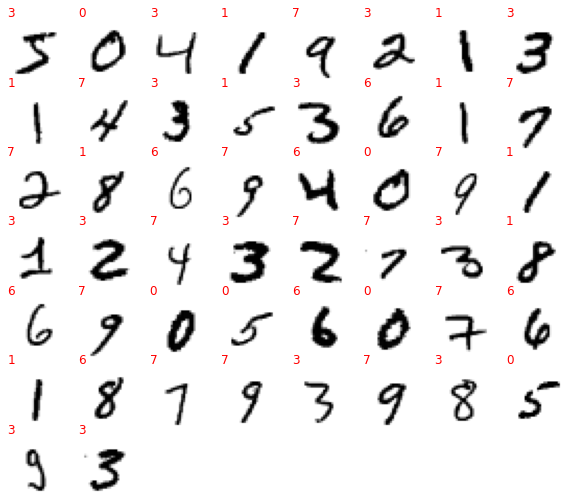

In [26]:
# 한 번에 여러 개 prediction
x = samples[0:64]
x = x.reshape(x.shape[0],784)
z, y = forward(x, W, b, V, c)
label_pred = np.argmax(y, axis=1)

figure = plt.figure(figsize=(10,10))
num_of_images = 50
for index in range(1,num_of_images+1):
    plt.subplot(8, 8, index)
    plt.imshow(x[index-1].reshape(28,28),cmap='gray_r')
    plt.axis('off')
    plt.title('{}'.format(label_pred[index-1]),loc='left',color='r')    